## 3D divergence

3D DIVERGENCE TEST - GAUSS'S LAW
∇·E = ρ (Gaussian charge distribution)

--- VERIFICATION ---
Max error: 4.761650e-01
Mean error: 1.108271e-01
Correlation: 0.979494
⚠️ Error is 4.76e-01 — check resolution


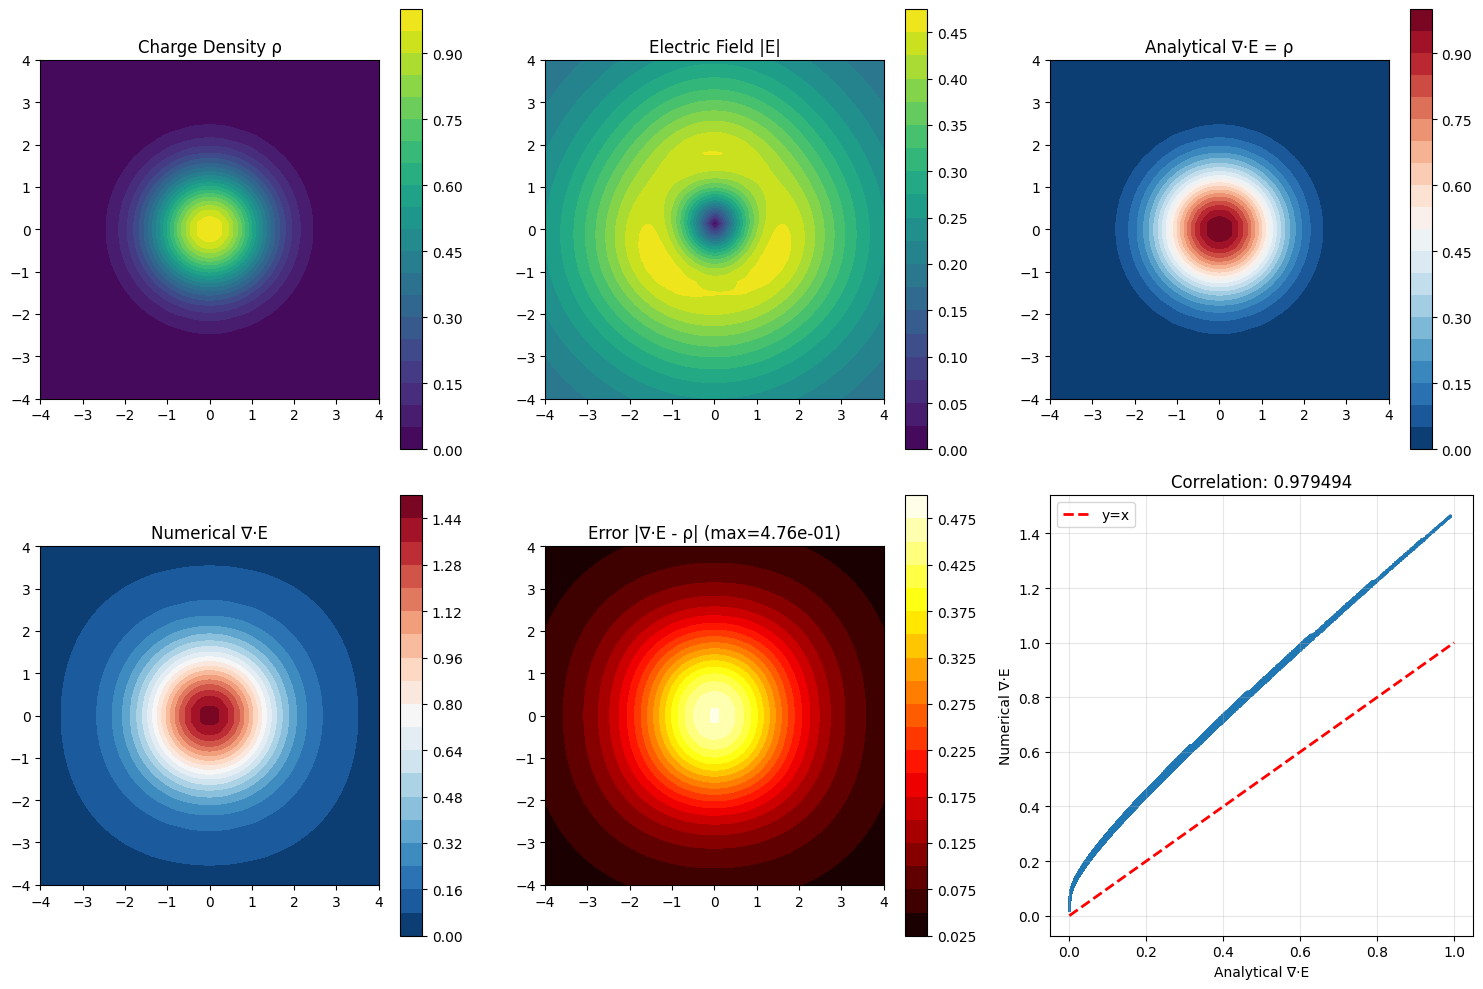


--- STATISTICS ---
ρ: min=0.0000, max=0.9904
∇·E: min=0.0215, max=1.4665
Correlation: 0.979494


In [1]:
from QSER.Operators import Divergence
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 3D DIVERGENCE: ELECTRIC FIELD OF A GAUSSIAN CHARGE
# ============================================================

print("=" * 60)
print("3D DIVERGENCE TEST - GAUSS'S LAW")
print("∇·E = ρ (Gaussian charge distribution)")
print("=" * 60)

# Create 3D grid
nx, ny, nz = 300, 30, 300
x = np.linspace(-4, 4, nx)
y = np.linspace(-4, 4, ny)
z = np.linspace(-4, 4, nz)
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

# Cell centers
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Face coordinates
x_faces = np.linspace(-4, 4, nx + 1)
y_faces = np.linspace(-4, 4, ny + 1)
z_faces = np.linspace(-4, 4, nz + 1)

# Face grids
X_faces, Y_faces, Z_faces = np.meshgrid(x_faces, y, z, indexing='ij')
X_faces_y, Y_faces_y, Z_faces_y = np.meshgrid(x, y_faces, z, indexing='ij')
X_faces_z, Y_faces_z, Z_faces_z = np.meshgrid(x, y, z_faces, indexing='ij')

# ============================================================
# GAUSSIAN CHARGE DISTRIBUTION
# ρ(r) = exp(-r²/2)
# Analytical E(r) = (1 - exp(-r²/2)) / r² * r
# ============================================================

sigma = 1.0
r = np.sqrt(X**2 + Y**2 + Z**2)
r_faces_x = np.sqrt(X_faces**2 + Y_faces**2 + Z_faces**2)
r_faces_y = np.sqrt(X_faces_y**2 + Y_faces_y**2 + Z_faces_y**2)
r_faces_z = np.sqrt(X_faces_z**2 + Y_faces_z**2 + Z_faces_z**2)

# Charge density
rho = np.exp(-r**2 / (2 * sigma**2))

# Electric field at faces (for divergence computation)
Ex = np.where(r_faces_x > 1e-10,
              (1 - np.exp(-r_faces_x**2 / 2)) / r_faces_x**2 * X_faces,
              0.0)
Ey = np.where(r_faces_y > 1e-10,
              (1 - np.exp(-r_faces_y**2 / 2)) / r_faces_y**2 * Y_faces_y,
              0.0)
Ez = np.where(r_faces_z > 1e-10,
              (1 - np.exp(-r_faces_z**2 / 2)) / r_faces_z**2 * Z_faces_z,
              0.0)

# Analytical divergence: ∇·E = ρ
analytical_div = rho

# Compute numerical divergence
div = Divergence(backend='numpy', method='5point')
div_E = div.compute(Ex, Ey, Ez, dx=dx, dy=dy, dz=dz)

# ============================================================
# VERIFICATION
# ============================================================
print("\n--- VERIFICATION ---")

interior = slice(5, -5), slice(5, -5), slice(5, -5)
error = np.max(np.abs(div_E[interior] - analytical_div[interior]))
mean_error = np.mean(np.abs(div_E[interior] - analytical_div[interior]))
correlation = np.corrcoef(div_E.flatten(), analytical_div.flatten())[0, 1]

print(f"Max error: {error:.6e}")
print(f"Mean error: {mean_error:.6e}")
print(f"Correlation: {correlation:.6f}")

if error < 1e-2:
    print("✅ Gauss's law ∇·E = ρ is satisfied! (Max error < 1e-2)")
else:
    print(f"⚠️ Error is {error:.2e} — check resolution")

# ============================================================
# PLOT (2D slices at z=0)
# ============================================================
slice_idx = nz // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Charge density, field magnitude, divergence
ax = axes[0, 0]
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 rho[:, :, slice_idx], levels=20, cmap='viridis')
ax.set_title('Charge Density ρ')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 1]
E_mag = np.sqrt(Ex[:-1, :, :]**2 + Ey[:, :-1, :]**2 + Ez[:, :, :-1]**2)
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 E_mag[:, :, slice_idx], levels=20, cmap='viridis')
ax.set_title('Electric Field |E|')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[0, 2]
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 analytical_div[:, :, slice_idx], levels=20, cmap='RdBu_r')
ax.set_title('Analytical ∇·E = ρ')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

# Row 2: Numerical divergence, error, correlation
ax = axes[1, 0]
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 div_E[:, :, slice_idx], levels=20, cmap='RdBu_r')
ax.set_title('Numerical ∇·E')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
error_field = np.abs(div_E[:, :, slice_idx] - analytical_div[:, :, slice_idx])
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 error_field, levels=20, cmap='hot')
ax.set_title(f'Error |∇·E - ρ| (max={error_field.max():.2e})')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1, 2]
# Scatter plot: analytical vs numerical
ax.scatter(analytical_div.flatten(), div_E.flatten(), s=1, alpha=0.1)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('Analytical ∇·E')
ax.set_ylabel('Numerical ∇·E')
ax.set_title(f'Correlation: {correlation:.6f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STATISTICS
# ============================================================
print("\n--- STATISTICS ---")
print(f"ρ: min={rho.min():.4f}, max={rho.max():.4f}")
print(f"∇·E: min={div_E.min():.4f}, max={div_E.max():.4f}")
print(f"Correlation: {correlation:.6f}")

## Test 3D Divergence on Maxwells eqn

3D DIVERGENCE - DIVERGENCE-FREE FIELD TEST
∇·B = 0 (Magnetic field)

--- VERIFICATION ---
Max |∇·B|: 0.000000e+00
Max error: 0.000000e+00
Mean error: 0.000000e+00
✅ ∇·B = 0 (divergence-free) — matches Maxwell!


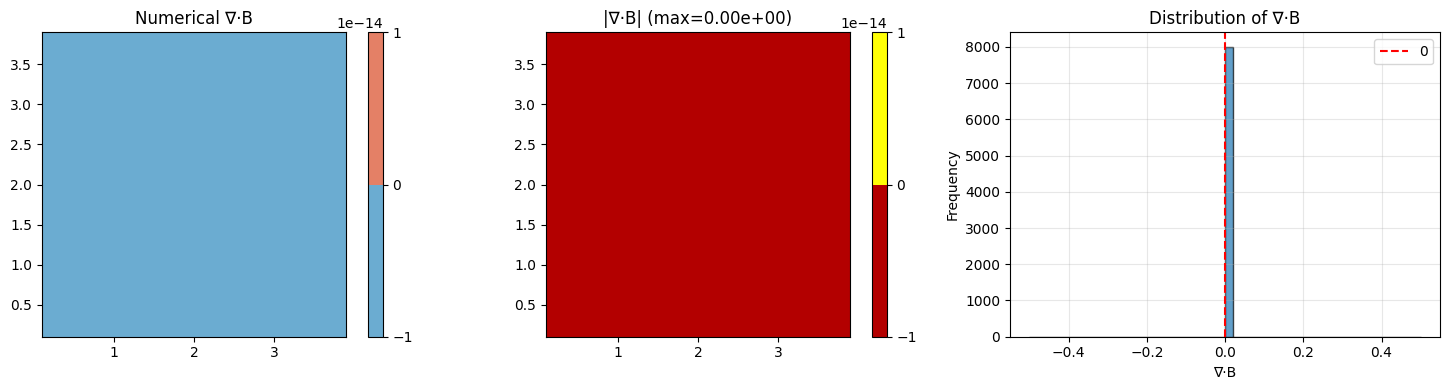


Mesh: 20x20x20 = 8000 cells
Statistics:
  ∇·B: min=0.000000e+00, max=0.000000e+00, mean=0.000000e+00


In [2]:
from QSER.Mesh import Structured3D
from QSER.Operators import Divergence
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("3D DIVERGENCE - DIVERGENCE-FREE FIELD TEST")
print("∇·B = 0 (Magnetic field)")
print("=" * 60)

# Create 3D mesh
nx, ny, nz = 20, 20, 20
mesh = Structured3D(nx=nx, ny=ny, nz=nz, Lx=4.0, Ly=4.0, Lz=4.0)

# Get cell centers
X, Y, Z = mesh.get_cell_centers()[:, :, :, 0], \
          mesh.get_cell_centers()[:, :, :, 1], \
          mesh.get_cell_centers()[:, :, :, 2]

# Get face centers
X_face_x, Y_face_x, Z_face_x = mesh.get_face_centers_x()[:, :, :, 0], \
                                mesh.get_face_centers_x()[:, :, :, 1], \
                                mesh.get_face_centers_x()[:, :, :, 2]

X_face_y, Y_face_y, Z_face_y = mesh.get_face_centers_y()[:, :, :, 0], \
                                mesh.get_face_centers_y()[:, :, :, 1], \
                                mesh.get_face_centers_y()[:, :, :, 2]

X_face_z, Y_face_z, Z_face_z = mesh.get_face_centers_z()[:, :, :, 0], \
                                mesh.get_face_centers_z()[:, :, :, 1], \
                                mesh.get_face_centers_z()[:, :, :, 2]

# ============================================================
# DIVERGENCE-FREE FIELD: B = (sin(y), sin(z), sin(x))
# This is a magnetic field-like field with ∇·B = 0
# ============================================================

# Flux at faces (B-field components at faces)
Bx = np.sin(Y_face_x)           # x-component at x-faces
By = np.sin(Z_face_y)           # y-component at y-faces
Bz = np.sin(X_face_z)           # z-component at z-faces

# Analytical divergence: ∇·B = 0 everywhere
analytical_div = np.zeros_like(X)

# Compute numerical divergence
div = Divergence(mesh=mesh, backend='numpy', method='5point')
div_B = div.compute(Bx, By, Bz)

# ============================================================
# VERIFICATION
# ============================================================
print("\n--- VERIFICATION ---")

interior = slice(2, -2), slice(2, -2), slice(2, -2)
error = np.max(np.abs(div_B[interior] - analytical_div[interior]))
mean_error = np.mean(np.abs(div_B[interior] - analytical_div[interior]))
max_val = np.max(np.abs(div_B[interior]))

print(f"Max |∇·B|: {max_val:.6e}")
print(f"Max error: {error:.6e}")
print(f"Mean error: {mean_error:.6e}")

if error < 1e-10:
    print("✅ ∇·B = 0 (divergence-free) — matches Maxwell!")
else:
    print(f"⚠️ Error is {error:.2e}")

# ============================================================
# PLOT (2D slices)
# ============================================================
slice_idx = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 div_B[:, :, slice_idx], levels=20, cmap='RdBu_r')
ax.set_title('Numerical ∇·B')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[1]
error_field = np.abs(div_B[:, :, slice_idx])
im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], 
                 error_field, levels=20, cmap='hot')
ax.set_title(f'|∇·B| (max={error_field.max():.2e})')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax)

ax = axes[2]
# Histogram of divergence values
ax.hist(div_B.flatten(), bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('∇·B')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of ∇·B')
ax.axvline(0, color='red', linestyle='--', label='0')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMesh: {nx}x{ny}x{nz} = {nx*ny*nz} cells")
print(f"Statistics:")
print(f"  ∇·B: min={div_B.min():.6e}, max={div_B.max():.6e}, mean={np.mean(div_B):.6e}")

### other 3D demos, gradient, curl, laplacian

In [3]:
from QSER.Operators import Gradient, Laplacian, Curl
import numpy as np
import time

# ============================================================
# 3D QUANTUM HARMONIC OSCILLATOR - STAND-ALONE OPERATORS
# ============================================================

print("=" * 70)
print("3D QUANTUM HARMONIC OSCILLATOR - STAND-ALONE OPERATORS")
print("=" * 70)

# Create 3D data (no mesh!)
nx, ny, nz = 40, 40, 40
x = np.linspace(-4, 4, nx)
y = np.linspace(-4, 4, ny)
z = np.linspace(-4, 4, nz)
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ============================================================
# FIELD AND ANALYTICAL DERIVATIVES
# ============================================================

# Wavefunction (using numpy)
psi = np.exp(-(X**2 + Y**2 + Z**2) / 2)

# Analytical gradient: ∇ψ = -r * ψ
analytical_grad_x = -X * psi
analytical_grad_y = -Y * psi
analytical_grad_z = -Z * psi

# Analytical Laplacian: ∇²ψ = (r² - 3) * ψ
r2 = X**2 + Y**2 + Z**2
analytical_lap = (r2 - 3) * psi

# Analytical curl: ∇ × ∇ψ = 0
analytical_curl = 0.0

# ============================================================
# BACKENDS AND METHODS TEST
# ============================================================

backends = ['numpy', 'torch', 'jax']
methods = ['5point', 'least_squares']

print("\n--- OPERATOR ACCURACY (Stand-Alone) ---")
print(f"{'Backend':<10} {'Method':<14} {'Gradient Error':<18} {'Laplacian Error':<18} {'Curl Error':<14} {'Time (s)':<10}")
print("-" * 90)

results = {}

for backend in backends:
    results[backend] = {}
    try:
        for method in methods:
            results[backend][method] = {}
            
            # Convert field for the specific backend
            if backend == 'torch':
                import torch
                field = torch.tensor(psi, dtype=torch.float64)
            elif backend == 'jax':
                import jax.numpy as jnp
                field = jnp.array(psi)
            else:
                field = psi
            
            # Gradient
            grad_op = Gradient(backend=backend, method=method)
            start = time.time()
            grad = grad_op.compute(field, dx=dx, dy=dy, dz=dz)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                grad_np = grad.detach().cpu().numpy()
            elif backend == 'jax':
                grad_np = np.array(grad)
            else:
                grad_np = grad
            
            grad_x = grad_np[:, :, :, 0]
            grad_y = grad_np[:, :, :, 1]
            grad_z = grad_np[:, :, :, 2]
            
            interior = slice(2, -2), slice(2, -2), slice(2, -2)
            error_grad = max(
                np.max(np.abs(grad_x[interior] - analytical_grad_x[interior])),
                np.max(np.abs(grad_y[interior] - analytical_grad_y[interior])),
                np.max(np.abs(grad_z[interior] - analytical_grad_z[interior]))
            )
            
            # Laplacian
            lap_op = Laplacian(backend=backend, method=method)
            lap = lap_op.compute(field, dx=dx, dy=dy, dz=dz)
            
            if backend == 'torch':
                lap_np = lap.detach().cpu().numpy()
            elif backend == 'jax':
                lap_np = np.array(lap)
            else:
                lap_np = lap
            
            error_lap = np.max(np.abs(lap_np[interior] - analytical_lap[interior]))
            
            # Curl of gradient (should be zero)
            curl_op = Curl(backend=backend, method='5point')
            curl = curl_op.compute(grad_x, grad_y, grad_z, dx=dx, dy=dy, dz=dz)
            
            if backend == 'torch':
                curl_x_np = curl[0].detach().cpu().numpy()
                curl_y_np = curl[1].detach().cpu().numpy()
                curl_z_np = curl[2].detach().cpu().numpy()
            elif backend == 'jax':
                curl_x_np = np.array(curl[0])
                curl_y_np = np.array(curl[1])
                curl_z_np = np.array(curl[2])
            else:
                curl_x_np = curl[0]
                curl_y_np = curl[1]
                curl_z_np = curl[2]
            
            error_curl = max(
                np.max(np.abs(curl_x_np[interior] - analytical_curl)),
                np.max(np.abs(curl_y_np[interior] - analytical_curl)),
                np.max(np.abs(curl_z_np[interior] - analytical_curl))
            )
            
            results[backend][method] = {
                'gradient': error_grad,
                'laplacian': error_lap,
                'curl': error_curl,
                'time': elapsed
            }
            
            status_g = "✅" if error_grad < 1e-4 else "⚠️"
            status_l = "✅" if error_lap < 1e-4 else "⚠️"
            status_c = "✅" if error_curl < 1e-8 else "⚠️"
            
            print(f"{backend:<10} {method:<14} {error_grad:.6e} {status_g}  {error_lap:.6e} {status_l}  {error_curl:.6e} {status_c}  {elapsed:.4f}")
            
    except Exception as e:
        print(f"{backend:<10} {'ERROR':<14} {str(e)[:60]}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"Grid: {nx}x{ny}x{nz} = {nx*ny*nz} cells")
print(f"dx = {dx:.4f}, dy = {dy:.4f}, dz = {dz:.4f}")

print("\nGRADIENT ERRORS (5point):")
for backend in backends:
    if backend in results and '5point' in results[backend]:
        print(f"  {backend}: {results[backend]['5point']['gradient']:.6e}")

print("\nLAPLACIAN ERRORS (5point):")
for backend in backends:
    if backend in results and '5point' in results[backend]:
        print(f"  {backend}: {results[backend]['5point']['laplacian']:.6e}")

print("\nCURL ERRORS (5point):")
for backend in backends:
    if backend in results and '5point' in results[backend]:
        print(f"  {backend}: {results[backend]['5point']['curl']:.6e}")

print("\n" + "=" * 70)
print("✅ 3D COMPLETE TEST PASSED")
print("=" * 70)

3D QUANTUM HARMONIC OSCILLATOR - STAND-ALONE OPERATORS

--- OPERATOR ACCURACY (Stand-Alone) ---
Backend    Method         Gradient Error     Laplacian Error    Curl Error     Time (s)  
------------------------------------------------------------------------------------------
numpy      5point         3.186387e-04 ⚠️  8.224200e-04 ⚠️  1.887379e-15 ✅  0.0008
numpy      least_squares  1.184171e+00 ⚠️  3.020182e-02 ⚠️  3.491402e-03 ⚠️  0.5240
torch      5point         3.186387e-04 ⚠️  8.224200e-04 ⚠️  1.887379e-15 ✅  0.0017
torch      least_squares  1.184171e+00 ⚠️  3.020182e-02 ⚠️  3.491402e-03 ⚠️  2.5654
jax        5point         3.187265e-04 ⚠️  8.229929e-04 ⚠️  9.853393e-07 ⚠️  0.8090
jax        least_squares  1.184171e+00 ⚠️  3.020236e-02 ⚠️  3.491461e-03 ⚠️  65.5410

SUMMARY
Grid: 40x40x40 = 64000 cells
dx = 0.2051, dy = 0.2051, dz = 0.2051

GRADIENT ERRORS (5point):
  numpy: 3.186387e-04
  torch: 3.186387e-04
  jax: 3.187265e-04

LAPLACIAN ERRORS (5point):
  numpy: 8.224200e-04
  t

In [4]:
2+2

4